# Malimg — Variante B : ResNet18 fine-tuné + descripteur GIST-style + SVM

Ce notebook est conçu pour **Kaggle** et reprend les mêmes chemins et paramètres de base que ton notebook CNN :

- `DATA_DIR = /kaggle/input/datasets/omarbabbou/malimg/dataset`
- `OUTPUT_DIR = /kaggle/working`
- `IMAGE_SIZE = 224`
- `BATCH_SIZE = 32`
- `NUM_WORKERS = 2`
- `RANDOM_SEED = 42`
- split **80 / 10 / 10** stratifié

Pipeline complet :

1. Chargement du dataset Malimg.
2. Split stratifié train / val / test.
3. Fine-tuning de **ResNet18**.
4. Évaluation de ResNet18 seul.
5. Extraction des features profondes ResNet18.
6. Extraction d’un **descripteur GIST-style** (implémentation locale sans dépendance externe fragile).
7. Fusion des features **ResNet18 + GIST-style**.
8. Entraînement d’un **SVM**.
9. Comparaison finale.

In [1]:
!pip show torch torchvision torchaudio

Name: torch
Version: 2.10.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, easyocr, fastai, kornia, peft, pytorch-ignite, pytorch-lightning, sentence-transformers, timm, torchaudio, torchdata, torchmetrics, torchvision
---
Name: torchvision
Version: 0.25.0+cu128
Summary: image and video datasets and models for torch deep learning
Home-page: h

In [2]:
!pip list | grep torch

pytorch-ignite                           0.5.3
pytorch-lightning                        2.6.1
torch                                    2.10.0+cu128
torchao                                  0.10.0
torchaudio                               2.10.0+cu128
torchcodec                               0.10.0+cu128
torchdata                                0.11.0
torchinfo                                1.8.0
torchmetrics                             1.9.0
torchsummary                             1.5.1
torchtune                                0.6.1
torchvision                              0.25.0+cu128


In [3]:
import site, sys
print("Python:", sys.executable)
print("site-packages:")
for p in site.getsitepackages():
    print(" -", p)

Python: /usr/bin/python3
site-packages:
 - /usr/local/lib/python3.12/dist-packages
 - /usr/lib/python3/dist-packages
 - /usr/lib/python3.12/dist-packages


In [4]:
# =========================================================
# 1) Imports + configuration globale
# =========================================================
import os
import time
import math
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from scipy import ndimage as ndi
from skimage.filters import gabor_kernel

warnings.filterwarnings("ignore")

# --- Kaggle paths ---
DATA_DIR   = Path("/kaggle/input/datasets/omarbabbou/malimg/dataset")
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Shared parameters from your CNN notebook ---
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2
RANDOM_SEED = 42
NUM_EPOCHS  = 15
LEARNING_RATE = 1e-4   # lower LR than custom CNN because we fine-tune ResNet18
WEIGHT_DECAY = 1e-4

# same idea as your previous notebook: choose one imbalance strategy only
EXPERIMENT = "sampler_only"          # other option: "weighted_loss_only"
# EXPERIMENT = "weighted_loss_only"

# reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = torch.cuda.is_available()

print(f"DATA_DIR exists : {DATA_DIR.exists()}")
print(f"OUTPUT_DIR      : {OUTPUT_DIR}")
print(f"Device          : {device}")
print(f"Experiment      : {EXPERIMENT}")

DATA_DIR exists : True
OUTPUT_DIR      : /kaggle/working
Device          : cuda
Experiment      : sampler_only


Number of families: 25
Total images      : 9348

Small sample of classes:
  Adialer.C                  122 images
  Agent.FYI                  116 images
  Allaple.A                 2958 images
  Allaple.L                 1591 images
  Alueron.gen!J              198 images
  Autorun.K                  106 images
  C2LOP.P                    146 images
  C2LOP.gen!g                200 images
  Dialplatform.B             177 images
  Dontovo.A                  162 images


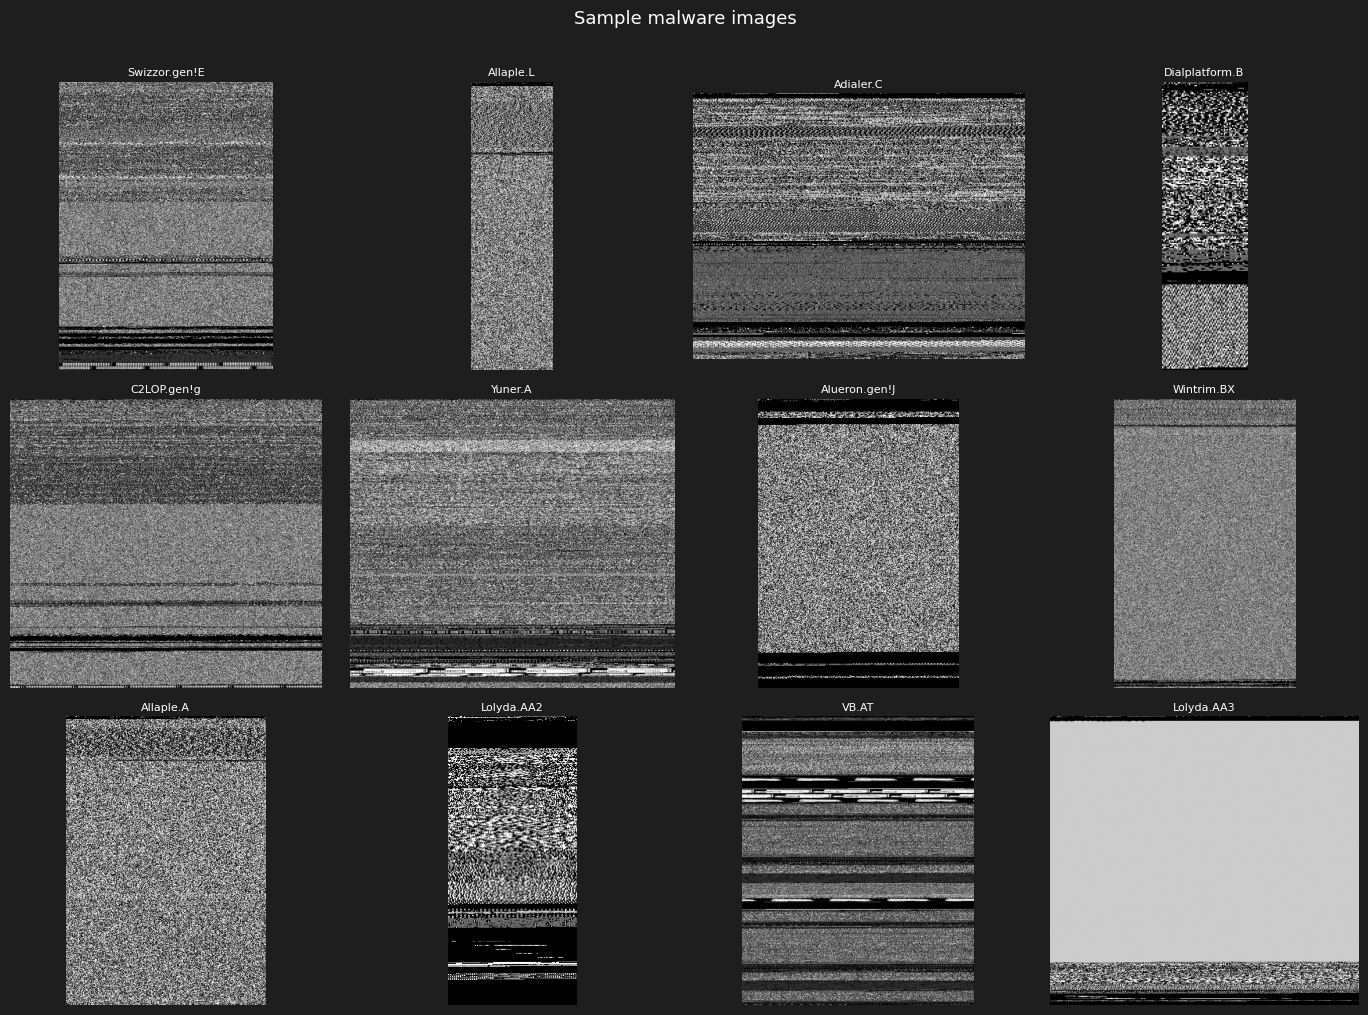

In [5]:
# =========================================================
# 2) Quick dataset overview (optional but useful)
# =========================================================
families = sorted([f.name for f in DATA_DIR.iterdir() if f.is_dir()])
counts = [len(list((DATA_DIR / family).glob("*.png"))) for family in families]

print(f"Number of families: {len(families)}")
print(f"Total images      : {sum(counts)}")
print()
print("Small sample of classes:")
for name, count in list(zip(families, counts))[:10]:
    print(f"  {name:<25} {count:>4} images")

# sample grid
sample_families = random.sample(families, min(12, len(families)))
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.patch.set_facecolor('#1e1e1e')
axes = axes.flatten()

for ax in axes:
    ax.axis('off')

for i, family in enumerate(sample_families):
    img_paths = list((DATA_DIR / family).glob("*.png"))
    img = Image.open(random.choice(img_paths)).convert('L')
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(family, color='white', fontsize=8, pad=4)
    axes[i].axis('off')

plt.suptitle('Sample malware images', color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'family_samples_variantB.png', dpi=120,
            bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

In [6]:
# =========================================================
# 3) Transforms for ResNet18
# =========================================================
# ResNet18 is pretrained on ImageNet, so we use ImageNet normalization.
# Malware images are grayscale, so we repeat the channel 3 times.

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms ready.")
print(f"Train transform steps   : {len(train_transform.transforms)}")
print(f"Val/Test transform steps: {len(val_transform.transforms)}")

Transforms ready.
Train transform steps   : 6
Val/Test transform steps: 4


In [7]:
# =========================================================
# 4) Load full dataset + class mapping
# =========================================================
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)
class_names = full_dataset.classes
num_classes = len(class_names)
all_labels = np.array(full_dataset.targets)

print(f"Total images loaded : {len(full_dataset)}")
print(f"Number of classes   : {num_classes}")
print()
print("Class index mapping:")
for idx, name in enumerate(class_names):
    print(f"  {idx:>2} -> {name}")

Total images loaded : 9348
Number of classes   : 25

Class index mapping:
   0 -> Adialer.C
   1 -> Agent.FYI
   2 -> Allaple.A
   3 -> Allaple.L
   4 -> Alueron.gen!J
   5 -> Autorun.K
   6 -> C2LOP.P
   7 -> C2LOP.gen!g
   8 -> Dialplatform.B
   9 -> Dontovo.A
  10 -> Fakerean
  11 -> Instantaccess
  12 -> Lolyda.AA1
  13 -> Lolyda.AA2
  14 -> Lolyda.AA3
  15 -> Lolyda.AT
  16 -> Malex.gen!J
  17 -> Obfuscator.AD
  18 -> Rbot!gen
  19 -> Skintrim.N
  20 -> Swizzor.gen!E
  21 -> Swizzor.gen!I
  22 -> VB.AT
  23 -> Wintrim.BX
  24 -> Yuner.A


In [8]:
# =========================================================
# 5) Stratified split: 80 / 10 / 10
# =========================================================
train_idx, temp_idx = train_test_split(
    np.arange(len(full_dataset)),
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=all_labels
)

temp_labels = all_labels[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=temp_labels
)

print(f"Train set : {len(train_idx):>5} images ({len(train_idx)/len(full_dataset)*100:.1f}%)")
print(f"Val set   : {len(val_idx):>5} images ({len(val_idx)/len(full_dataset)*100:.1f}%)")
print(f"Test set  : {len(test_idx):>5} images ({len(test_idx)/len(full_dataset)*100:.1f}%)")
print(f"Total     : {len(train_idx)+len(val_idx)+len(test_idx):>5} images")

family_to_check = "Allaple.A" if "Allaple.A" in class_names else class_names[0]
idx_in_family = np.where(all_labels == class_names.index(family_to_check))[0]
in_train = len(np.intersect1d(idx_in_family, train_idx))
in_val   = len(np.intersect1d(idx_in_family, val_idx))
in_test  = len(np.intersect1d(idx_in_family, test_idx))
print()
print(f"Stratification check — {family_to_check}:")
print(f"  Train: {in_train}  Val: {in_val}  Test: {in_test}")

Train set :  7478 images (80.0%)
Val set   :   935 images (10.0%)
Test set  :   935 images (10.0%)
Total     :  9348 images

Stratification check — Allaple.A:
  Train: 2366  Val: 296  Test: 296


In [9]:
# =========================================================
# 6) Handle class imbalance (same philosophy as your CNN notebook)
# =========================================================
train_labels = all_labels[train_idx]
class_counts = np.bincount(train_labels, minlength=num_classes)

print("Training images per class:")
for i, (name, count) in enumerate(zip(class_names, class_counts)):
    print(f"  {i:>2} {name:<25} {count:>5} images")

train_sampler = None
loss_weights = None

if EXPERIMENT == "sampler_only":
    class_weights_sampler = 1.0 / np.maximum(class_counts, 1)
    sample_weights = class_weights_sampler[train_labels]
    sample_weights = torch.DoubleTensor(sample_weights)
    train_sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    print("Using WeightedRandomSampler.")

elif EXPERIMENT == "weighted_loss_only":
    class_weights_loss = 1.0 / np.maximum(class_counts, 1)
    class_weights_loss = class_weights_loss / class_weights_loss.mean()
    loss_weights = torch.tensor(class_weights_loss, dtype=torch.float32)
    print("Using weighted CrossEntropyLoss.")

else:
    raise ValueError("EXPERIMENT must be 'sampler_only' or 'weighted_loss_only'.")

Training images per class:
   0 Adialer.C                    98 images
   1 Agent.FYI                    93 images
   2 Allaple.A                  2366 images
   3 Allaple.L                  1273 images
   4 Alueron.gen!J               158 images
   5 Autorun.K                    85 images
   6 C2LOP.P                     117 images
   7 C2LOP.gen!g                 160 images
   8 Dialplatform.B              141 images
   9 Dontovo.A                   130 images
  10 Fakerean                    305 images
  11 Instantaccess               345 images
  12 Lolyda.AA1                  170 images
  13 Lolyda.AA2                  147 images
  14 Lolyda.AA3                   98 images
  15 Lolyda.AT                   127 images
  16 Malex.gen!J                 109 images
  17 Obfuscator.AD               114 images
  18 Rbot!gen                    126 images
  19 Skintrim.N                   64 images
  20 Swizzor.gen!E               102 images
  21 Swizzor.gen!I               106 images
  22 

In [10]:
# =========================================================
# 7) Create subsets + dataloaders
# =========================================================
train_dataset_full = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
eval_dataset_full  = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)

train_subset = Subset(train_dataset_full, train_idx)
val_subset   = Subset(eval_dataset_full,  val_idx)
test_subset  = Subset(eval_dataset_full,  test_idx)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=(train_sampler is None),
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print(f"Train subset : {len(train_subset)} images")
print(f"Val subset   : {len(val_subset)} images")
print(f"Test subset  : {len(test_subset)} images")
print()
print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

Train subset : 7478 images
Val subset   : 935 images
Test subset  : 935 images

Train batches: 234
Val batches  : 30
Test batches : 30


Batch image tensor shape: torch.Size([32, 3, 224, 224])
Batch labels shape      : torch.Size([32])


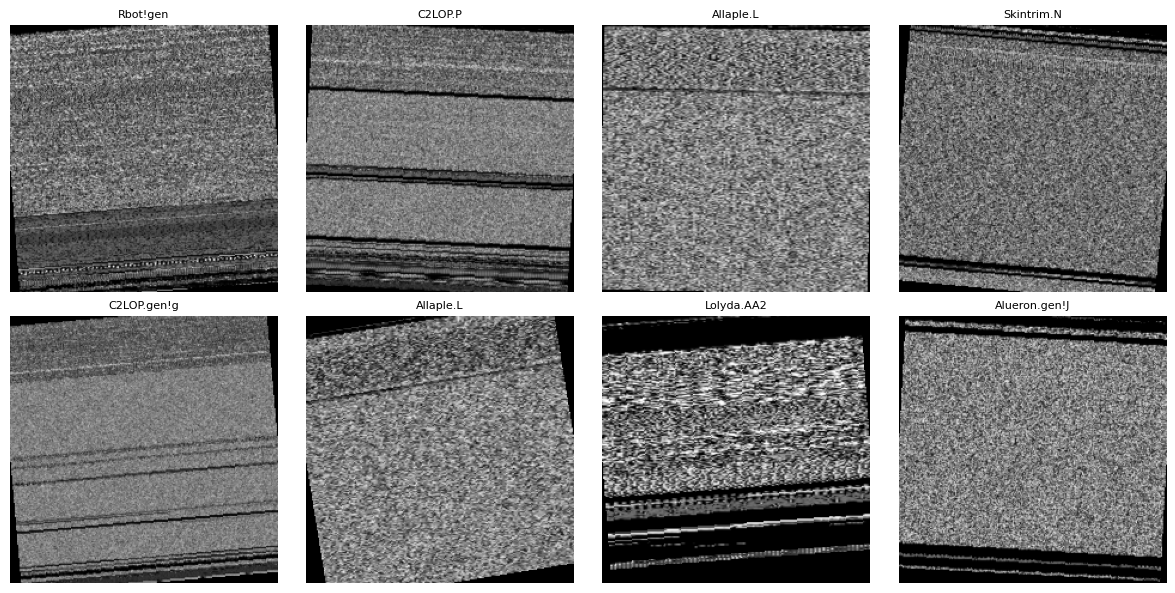

In [11]:
# =========================================================
# 8) Sanity check: one batch
# =========================================================
images, labels = next(iter(train_loader))
print(f"Batch image tensor shape: {images.shape}")
print(f"Batch labels shape      : {labels.shape}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i, ax in enumerate(axes):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * std) + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i].item()], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# =========================================================
# 9) Build ResNet18 and adapt final layer
# =========================================================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Option A: full fine-tuning
for param in model.parameters():
    param.requires_grad = True

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

if loss_weights is not None:
    criterion = nn.CrossEntropyLoss(weight=loss_weights.to(device))
    print("Loss function : weighted CrossEntropyLoss")
else:
    criterion = nn.CrossEntropyLoss()
    print("Loss function : normal CrossEntropyLoss")

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

SAVE_PATH_LOSS = OUTPUT_DIR / f"best_resnet18_loss_{EXPERIMENT}.pth"
SAVE_PATH_ACC  = OUTPUT_DIR / f"best_resnet18_acc_{EXPERIMENT}.pth"

print(model)
print()
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s] 


Loss function : normal CrossEntropyLoss
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

In [13]:
# =========================================================
# 10) Helper functions: evaluate + training loop
# =========================================================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples * 100
    return avg_loss, accuracy


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs):
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "lr": []
    }

    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0
    EARLY_STOP_PATIENCE = 8

    print("Starting training...")
    print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'LR':<10} {'Time'}")
    print("─" * 90)

    for epoch in range(1, epochs + 1):
        start_time = time.time()
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_samples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_samples += images.size(0)

        train_loss /= train_samples
        train_acc = train_correct / train_samples * 100

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        epoch_time = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # save best on val loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "val_loss": val_loss,
                "val_acc": val_acc,
                "class_names": class_names,
                "experiment": EXPERIMENT,
            }, SAVE_PATH_LOSS)
        else:
            epochs_no_improve += 1

        # save best on val acc
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "val_loss": val_loss,
                "val_acc": val_acc,
                "class_names": class_names,
                "experiment": EXPERIMENT,
            }, SAVE_PATH_ACC)

        print(f"{epoch:<8} {train_loss:<12.4f} {train_acc:<12.2f} {val_loss:<12.4f} {val_acc:<12.2f} {current_lr:<10.6f} {epoch_time:.1f}s")

        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"Early stopping triggered after {epoch} epochs.")
            break

    return history

In [14]:
# =========================================================
# 11) Train ResNet18
# =========================================================
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=NUM_EPOCHS
)

print()
print("Saved best checkpoints:")
print("  Best val loss ->", SAVE_PATH_LOSS)
print("  Best val acc  ->", SAVE_PATH_ACC)

Starting training...
Epoch    Train Loss   Train Acc    Val Loss     Val Acc      LR         Time
──────────────────────────────────────────────────────────────────────────────────────────
1        0.3119       89.97        0.0642       98.29        0.000100   87.3s
2        0.1021       94.81        0.0723       98.07        0.000100   49.2s
3        0.0867       94.88        0.0804       98.18        0.000100   38.1s
4        0.0791       95.31        0.0850       98.07        0.000100   38.6s
5        0.0715       95.61        0.0722       98.18        0.000050   59.3s
6        0.0529       97.33        0.0276       99.47        0.000050   55.1s
7        0.0171       99.37        0.0298       99.47        0.000050   59.7s
8        0.0081       99.80        0.0279       99.47        0.000050   52.1s
9        0.0074       99.81        0.0325       99.47        0.000050   52.5s
10       0.0051       99.85        0.0258       99.47        0.000050   52.3s
11       0.0023       99.92    

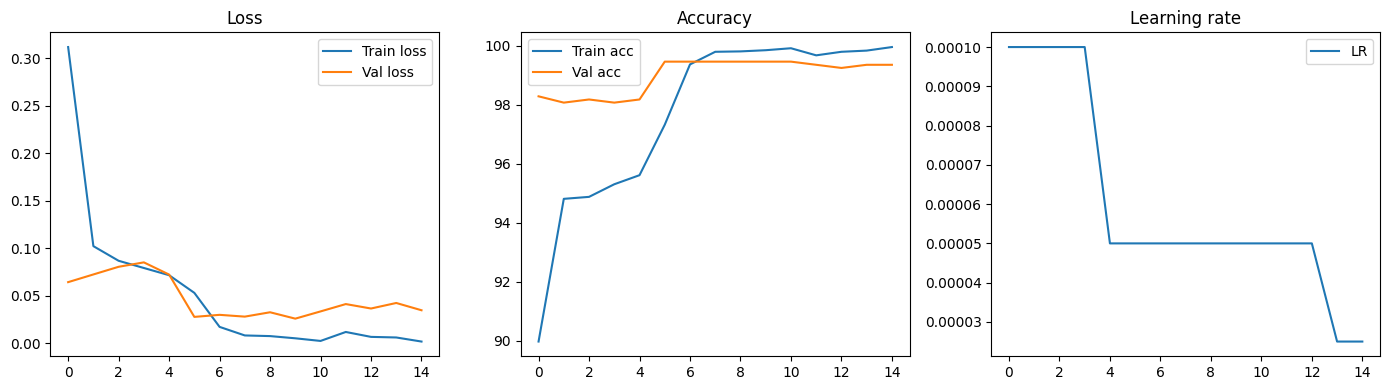

In [15]:
# =========================================================
# 12) Plot training curves
# =========================================================
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Val loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train acc')
plt.plot(history['val_acc'], label='Val acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['lr'], label='LR')
plt.title('Learning rate')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# =========================================================
# 13) Load best checkpoint (best val accuracy) and test ResNet18 alone
# =========================================================
CHECKPOINT_PATH = str(SAVE_PATH_ACC)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
model = model.to(device)
model.eval()

print("Loaded checkpoint:", CHECKPOINT_PATH)
print("Saved epoch:", checkpoint.get('epoch'))
print("Saved val loss:", checkpoint.get('val_loss'))
print("Saved val acc:", checkpoint.get('val_acc'))

# test loop
all_targets = []
all_preds = []
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        preds = outputs.argmax(dim=1)

        test_loss += loss.item() * images.size(0)
        all_targets.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)

test_loss /= len(test_loader.dataset)
resnet_test_acc = accuracy_score(all_targets, all_preds) * 100
resnet_macro_f1 = f1_score(all_targets, all_preds, average='macro')

print("── ResNet18 Test Results ─────────────────────")
print(f"Test Loss   : {test_loss:.4f}")
print(f"Test Acc    : {resnet_test_acc:.2f}%")
print(f"Macro F1    : {resnet_macro_f1:.4f}")

resnet_report = classification_report(
    all_targets,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0
)
print("── Classification Report (ResNet18) ─────────")
print(resnet_report)

Loaded checkpoint: /kaggle/working/best_resnet18_acc_sampler_only.pth
Saved epoch: 6
Saved val loss: 0.027618413258911692
Saved val acc: 99.46524064171123
── ResNet18 Test Results ─────────────────────
Test Loss   : 0.0147
Test Acc    : 99.79%
Macro F1    : 0.9949
── Classification Report (ResNet18) ─────────
                precision    recall  f1-score   support

     Adialer.C     1.0000    1.0000    1.0000        12
     Agent.FYI     1.0000    1.0000    1.0000        11
     Allaple.A     1.0000    1.0000    1.0000       296
     Allaple.L     1.0000    1.0000    1.0000       159
 Alueron.gen!J     1.0000    1.0000    1.0000        20
     Autorun.K     1.0000    1.0000    1.0000        10
       C2LOP.P     1.0000    1.0000    1.0000        15
   C2LOP.gen!g     1.0000    1.0000    1.0000        20
Dialplatform.B     1.0000    1.0000    1.0000        18
     Dontovo.A     1.0000    1.0000    1.0000        16
      Fakerean     1.0000    1.0000    1.0000        38
 Instantaccess  

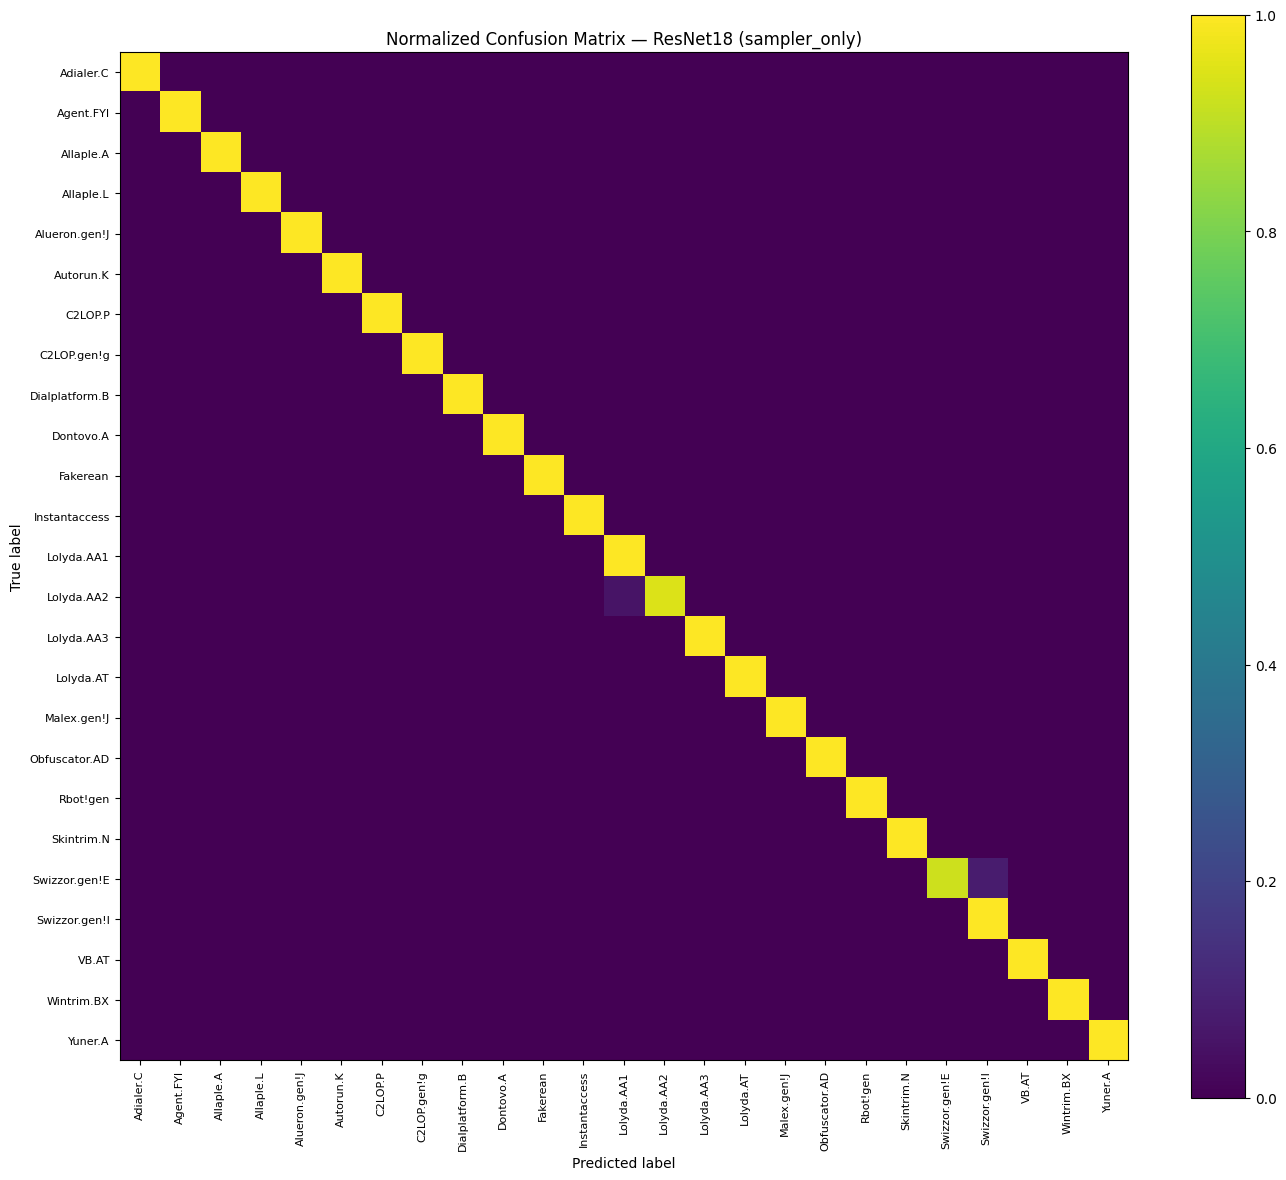

In [17]:
# =========================================================
# 14) Confusion matrix for ResNet18
# =========================================================
cm_resnet_norm = confusion_matrix(
    all_targets,
    all_preds,
    labels=list(range(len(class_names))),
    normalize='true'
)

plt.figure(figsize=(14, 12))
plt.imshow(cm_resnet_norm, interpolation='nearest')
plt.title(f'Normalized Confusion Matrix — ResNet18 ({EXPERIMENT})')
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90, fontsize=8)
plt.yticks(tick_marks, class_names, fontsize=8)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_resnet.png", dpi=300, bbox_inches="tight")

plt.show()

## GIST-style descriptor used here

Pour éviter une dépendance externe fragile sur Kaggle, ce notebook utilise une **implémentation locale de type GIST** basée sur :

- une banque de filtres de Gabor,
- une moyenne spatiale par blocs,
- une concaténation finale en un vecteur global.

Ce n’est pas un appel direct à `pyleargist`, mais c’est une implémentation pratique de l’idée **GIST / spatial envelope** pour garder le notebook exécutable de bout en bout sur Kaggle.

In [18]:
# =========================================================
# 15) Build GIST-style filter bank
# =========================================================
# Classical GIST uses several scales and orientations. Here we use a practical
# bank that stays light enough for Kaggle while still being meaningful.

GIST_IMAGE_SIZE = 128
GIST_GRID = 4
GIST_ORIENTATIONS_PER_SCALE = [8, 8, 4, 4]   # 24 filters total
GIST_FREQUENCIES = [0.10, 0.20, 0.30, 0.40]

def build_gist_kernels():
    kernels = []
    for freq, n_ori in zip(GIST_FREQUENCIES, GIST_ORIENTATIONS_PER_SCALE):
        for theta_idx in range(n_ori):
            theta = theta_idx / n_ori * np.pi
            kernel = np.real(gabor_kernel(frequency=freq, theta=theta, sigma_x=3, sigma_y=3))
            kernels.append(np.asarray(kernel, dtype=np.float32))
    return kernels

gist_kernels = build_gist_kernels()
print(f"Number of GIST-style kernels: {len(gist_kernels)}")
print(f"Expected descriptor size     : {len(gist_kernels) * GIST_GRID * GIST_GRID}")

Number of GIST-style kernels: 24
Expected descriptor size     : 384


In [19]:
# =========================================================
# 16) GIST-style descriptor extraction
# =========================================================
def compute_gist_descriptor_from_pil(img_pil, kernels, image_size=GIST_IMAGE_SIZE, grid=GIST_GRID):
    """
    Input  : PIL image
    Output : 1D float32 descriptor
    """
    img = img_pil.convert('L').resize((image_size, image_size))
    img = np.asarray(img, dtype=np.float32) / 255.0

    features = []
    block_h = image_size // grid
    block_w = image_size // grid

    for kernel in kernels:
        response = ndi.convolve(img, kernel, mode='reflect')
        response = np.abs(response)

        for gy in range(grid):
            for gx in range(grid):
                patch = response[
                    gy * block_h:(gy + 1) * block_h,
                    gx * block_w:(gx + 1) * block_w
                ]
                features.append(patch.mean())

    return np.asarray(features, dtype=np.float32)

# quick sanity check on one image
sample_path, sample_label = eval_dataset_full.samples[test_idx[0]]
sample_img = Image.open(sample_path)
sample_gist = compute_gist_descriptor_from_pil(sample_img, gist_kernels)
print("Sample file      :", sample_path)
print("Descriptor shape :", sample_gist.shape)
print("Class            :", class_names[sample_label])

Sample file      : /kaggle/input/datasets/omarbabbou/malimg/dataset/Yuner.A/0042f6d26e636e68d2700692ae616402.png
Descriptor shape : (384,)
Class            : Yuner.A


In [20]:
# =========================================================
# 17) Convert current fine-tuned ResNet18 into a feature extractor
# =========================================================
feature_extractor = nn.Sequential(*list(model.children())[:-1]).to(device)
feature_extractor.eval()

@torch.no_grad()
def extract_resnet_features_from_indices(dataset_full, indices, batch_size=64):
    subset = Subset(dataset_full, indices)
    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )

    features = []
    labels = []

    for images, y in loader:
        images = images.to(device)
        feats = feature_extractor(images)
        feats = feats.view(feats.size(0), -1).cpu().numpy()
        features.append(feats)
        labels.append(y.numpy())

    X = np.vstack(features).astype(np.float32)
    y = np.concatenate(labels)
    return X, y

In [21]:
# =========================================================
# 18) Extract deep features from ResNet18
# =========================================================
X_train_resnet, y_train_resnet = extract_resnet_features_from_indices(eval_dataset_full, train_idx)
X_val_resnet,   y_val_resnet   = extract_resnet_features_from_indices(eval_dataset_full, val_idx)
X_test_resnet,  y_test_resnet  = extract_resnet_features_from_indices(eval_dataset_full, test_idx)

print("ResNet feature shapes:")
print("  Train:", X_train_resnet.shape)
print("  Val  :", X_val_resnet.shape)
print("  Test :", X_test_resnet.shape)

ResNet feature shapes:
  Train: (7478, 512)
  Val  : (935, 512)
  Test : (935, 512)


In [22]:
# =========================================================
# 19) Extract GIST-style features using the SAME split indices order
# =========================================================
def extract_gist_features_from_indices(imagefolder_dataset, indices, kernels):
    X = []
    y = []

    for idx in indices:
        path, label = imagefolder_dataset.samples[idx]
        img = Image.open(path)
        feat = compute_gist_descriptor_from_pil(img, kernels)
        X.append(feat)
        y.append(label)

    return np.vstack(X).astype(np.float32), np.array(y)

start = time.time()
X_train_gist, y_train_gist = extract_gist_features_from_indices(eval_dataset_full, train_idx, gist_kernels)
X_val_gist,   y_val_gist   = extract_gist_features_from_indices(eval_dataset_full, val_idx, gist_kernels)
X_test_gist,  y_test_gist  = extract_gist_features_from_indices(eval_dataset_full, test_idx, gist_kernels)
end = time.time()

print("GIST-style feature shapes:")
print("  Train:", X_train_gist.shape)
print("  Val  :", X_val_gist.shape)
print("  Test :", X_test_gist.shape)
print(f"Extraction time: {(end - start)/60:.2f} min")

GIST-style feature shapes:
  Train: (7478, 384)
  Val  : (935, 384)
  Test : (935, 384)
Extraction time: 31.56 min


In [23]:
# =========================================================
# 20) Check label alignment before fusion
# =========================================================
print("Train labels aligned:", np.array_equal(y_train_resnet, y_train_gist))
print("Val labels aligned  :", np.array_equal(y_val_resnet, y_val_gist))
print("Test labels aligned :", np.array_equal(y_test_resnet, y_test_gist))

assert np.array_equal(y_train_resnet, y_train_gist)
assert np.array_equal(y_val_resnet, y_val_gist)
assert np.array_equal(y_test_resnet, y_test_gist)

y_train = y_train_resnet
y_val   = y_val_resnet
y_test  = y_test_resnet

Train labels aligned: True
Val labels aligned  : True
Test labels aligned : True


In [24]:
# =========================================================
# 21) Feature fusion + scaling
# =========================================================
X_train_fused = np.concatenate([X_train_resnet, X_train_gist], axis=1)
X_val_fused   = np.concatenate([X_val_resnet,   X_val_gist],   axis=1)
X_test_fused  = np.concatenate([X_test_resnet,  X_test_gist],  axis=1)

print("Fused feature shapes:")
print("  Train:", X_train_fused.shape)
print("  Val  :", X_val_fused.shape)
print("  Test :", X_test_fused.shape)

scaler = StandardScaler()
X_train_fused_scaled = scaler.fit_transform(X_train_fused)
X_val_fused_scaled   = scaler.transform(X_val_fused)
X_test_fused_scaled  = scaler.transform(X_test_fused)

Fused feature shapes:
  Train: (7478, 896)
  Val  : (935, 896)
  Test : (935, 896)


In [25]:
# =========================================================
# 22) Train SVM on fused features
# =========================================================
# RBF kernel is a strong default. Training is done on CPU via scikit-learn.
svm_clf = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    class_weight='balanced',
    probability=True
)

start = time.time()
svm_clf.fit(X_train_fused_scaled, y_train)
svm_train_time = time.time() - start

print(f"SVM training done in {svm_train_time:.1f} seconds")

SVM training done in 9.6 seconds


In [26]:
# =========================================================
# 23) Evaluate SVM (final Variante B model)
# =========================================================
y_pred_svm = svm_clf.predict(X_test_fused_scaled)

svm_test_acc = accuracy_score(y_test, y_pred_svm) * 100
svm_macro_f1 = f1_score(y_test, y_pred_svm, average='macro')

svm_report = classification_report(
    y_test,
    y_pred_svm,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("── Final Model: GIST-style + ResNet18 + SVM ─────────")
print(f"Test Acc : {svm_test_acc:.2f}%")
print(f"Macro F1 : {svm_macro_f1:.4f}")
print("── Classification Report (SVM) ──────────────────────")
print(svm_report)

── Final Model: GIST-style + ResNet18 + SVM ─────────
Test Acc : 99.68%
Macro F1 : 0.9919
── Classification Report (SVM) ──────────────────────
                precision    recall  f1-score   support

     Adialer.C     1.0000    1.0000    1.0000        12
     Agent.FYI     1.0000    1.0000    1.0000        11
     Allaple.A     1.0000    1.0000    1.0000       296
     Allaple.L     1.0000    1.0000    1.0000       159
 Alueron.gen!J     1.0000    1.0000    1.0000        20
     Autorun.K     1.0000    1.0000    1.0000        10
       C2LOP.P     1.0000    1.0000    1.0000        15
   C2LOP.gen!g     1.0000    1.0000    1.0000        20
Dialplatform.B     1.0000    1.0000    1.0000        18
     Dontovo.A     1.0000    1.0000    1.0000        16
      Fakerean     1.0000    1.0000    1.0000        38
 Instantaccess     1.0000    1.0000    1.0000        43
    Lolyda.AA1     0.9565    1.0000    0.9778        22
    Lolyda.AA2     1.0000    0.9474    0.9730        19
    Lolyda.AA3 

In [27]:
# =========================================================
# 25) Save artifacts to /kaggle/working
# =========================================================
# Save numpy features for later analysis or report figures
np.save(OUTPUT_DIR / f"X_train_resnet_{EXPERIMENT}.npy", X_train_resnet)
np.save(OUTPUT_DIR / f"X_val_resnet_{EXPERIMENT}.npy",   X_val_resnet)
np.save(OUTPUT_DIR / f"X_test_resnet_{EXPERIMENT}.npy",  X_test_resnet)

np.save(OUTPUT_DIR / f"X_train_giststyle_{EXPERIMENT}.npy", X_train_gist)
np.save(OUTPUT_DIR / f"X_val_giststyle_{EXPERIMENT}.npy",   X_val_gist)
np.save(OUTPUT_DIR / f"X_test_giststyle_{EXPERIMENT}.npy",  X_test_gist)

np.save(OUTPUT_DIR / f"X_train_fused_{EXPERIMENT}.npy", X_train_fused)
np.save(OUTPUT_DIR / f"X_val_fused_{EXPERIMENT}.npy",   X_val_fused)
np.save(OUTPUT_DIR / f"X_test_fused_{EXPERIMENT}.npy",  X_test_fused)

# Save torch checkpoint of best ResNet18 already done above; here we save a compact summary too
summary_path = OUTPUT_DIR / f"summary_variantB_{EXPERIMENT}.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("Malimg - Variante B")
    f.write(f"Experiment: {EXPERIMENT}")
    f.write(f"Device: {device}")
    f.write(f"ResNet18 test accuracy: {resnet_test_acc:.2f}%")
    f.write(f"ResNet18 macro F1: {resnet_macro_f1:.4f}")
    f.write(f"Final SVM test accuracy: {svm_test_acc:.2f}%")
    f.write(f"Final SVM macro F1: {svm_macro_f1:.4f}")
    f.write("--- ResNet18 report ---")
    f.write(resnet_report)
    f.write("--- Final SVM report ---")
    f.write(svm_report)

print("Saved summary to:", summary_path)
print("Saved feature arrays to /kaggle/working")

Saved summary to: /kaggle/working/summary_variantB_sampler_only.txt
Saved feature arrays to /kaggle/working


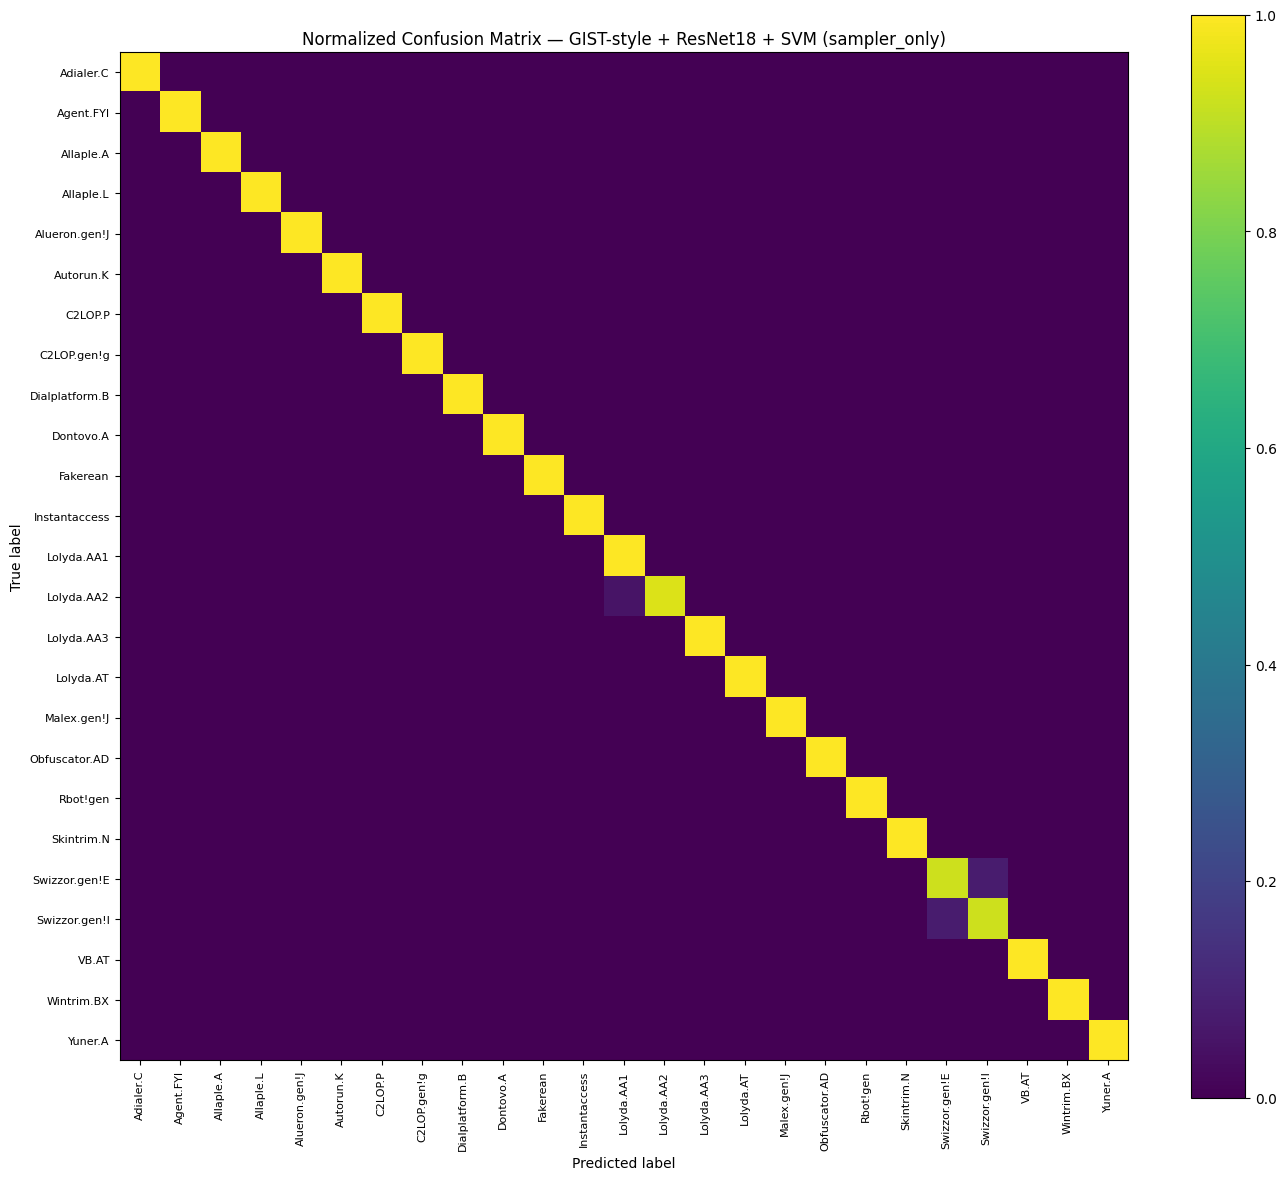

In [28]:
# =========================================================
# 24) Confusion matrix for final SVM model
# =========================================================
cm_svm_norm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=list(range(len(class_names))),
    normalize='true',
)

plt.figure(figsize=(14, 12))
plt.imshow(cm_svm_norm, interpolation='nearest')
plt.title(f'Normalized Confusion Matrix — GIST-style + ResNet18 + SVM ({EXPERIMENT})')
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90, fontsize=8)
plt.yticks(tick_marks, class_names, fontsize=8)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_svm.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
import joblib

joblib.dump(svm_clf, "/kaggle/working/svm_clf.joblib")
print("SVM saved to /kaggle/working/svm_clf.joblib")

In [29]:
# =========================================================
# 26) Final comparison table
# =========================================================
# Fill CNN_BASELINE_ACC / CNN_BASELINE_F1 with the values from your first notebook
CNN_BASELINE_ACC = None
CNN_BASELINE_F1  = None

results_rows = [
    ["CNN baseline", CNN_BASELINE_ACC, CNN_BASELINE_F1],
    ["ResNet18 fine-tuned", round(resnet_test_acc, 2), round(resnet_macro_f1, 4)],
    ["GIST-style + ResNet18 + SVM", round(svm_test_acc, 2), round(svm_macro_f1, 4)],
]

print(f"{'Model':<30} {'Accuracy (%)':<15} {'Macro F1'}")
print("-" * 60)
for row in results_rows:
    print(f"{row[0]:<30} {str(row[1]):<15} {row[2]}")

Model                          Accuracy (%)    Macro F1
------------------------------------------------------------
CNN baseline                   None            None
ResNet18 fine-tuned            99.79           0.9949
GIST-style + ResNet18 + SVM    99.68           0.9919


In [31]:
import os

zip_path = "/kaggle/working/my_project.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)
    print("Deleted:", zip_path)
else:
    print("File not found:", zip_path)

Deleted: /kaggle/working/my_project.zip


In [ ]:
import joblib
import json

# Save the fitted scaler
joblib.dump(scaler, OUTPUT_DIR / "scaler.joblib")

# Save the trained SVM
joblib.dump(svm_clf, OUTPUT_DIR / "svm.joblib")

# Save class names
json.dump(class_names, open(OUTPUT_DIR / "class_names.json", "w"), indent=2)

print("Saved:")
print(f"  {OUTPUT_DIR / 'scaler.joblib'}")
print(f"  {OUTPUT_DIR / 'svm.joblib'}")
print(f"  {OUTPUT_DIR / 'class_names.json'}")


In [ ]:
# === Final export cell: package notebook + everything in /kaggle/working into one ZIP ===
import os
import shutil
import zipfile

WORKING_DIR = "/kaggle/working"
NOTEBOOK_COPY = os.path.join(WORKING_DIR, "notebook_copy.ipynb")
ZIP_PATH = os.path.join(WORKING_DIR, "kaggle_run_all_outputs.zip")

# Try to copy the running notebook source if available in Kaggle
possible_notebook_sources = [
    "/kaggle/working/.virtual_documents/__notebook_source__.ipynb",
    "/kaggle/input/__notebook_source__.ipynb",
]

copied = False
for src_path in possible_notebook_sources:
    if os.path.exists(src_path):
        shutil.copy2(src_path, NOTEBOOK_COPY)
        copied = True
        print(f"Notebook copied from: {src_path}")
        break

if not copied:
    print("Notebook source not found automatically. ZIP will still be created from /kaggle/working.")

# Create zip with everything currently in /kaggle/working except the zip itself
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(WORKING_DIR):
        for file in files:
            full_path = os.path.join(root, file)

            # Skip the zip file itself to avoid recursion
            if os.path.abspath(full_path) == os.path.abspath(ZIP_PATH):
                continue

            arcname = os.path.relpath(full_path, WORKING_DIR)
            zipf.write(full_path, arcname)

print(f"\nZIP created successfully: {ZIP_PATH}")
print("\nFiles currently in /kaggle/working:")
for root, dirs, files in os.walk(WORKING_DIR):
    for file in files:
        print(os.path.join(root, file))

In [ ]:
import joblib
import json

# Save the fitted scaler
joblib.dump(scaler, OUTPUT_DIR / "scaler.joblib")

# Save the trained SVM
joblib.dump(svm_clf, OUTPUT_DIR / "svm.joblib")

# Save class names
json.dump(class_names, open(OUTPUT_DIR / "class_names.json", "w"), indent=2)

print("Saved:")
print(f"  {OUTPUT_DIR / 'scaler.joblib'}")
print(f"  {OUTPUT_DIR / 'svm.joblib'}")
print(f"  {OUTPUT_DIR / 'class_names.json'}")

In [ ]:
import tarfile
import os

archive_path = "/kaggle/working/full_project.tar"

# supprimer l'ancienne archive si elle existe
if os.path.exists(archive_path):
    os.remove(archive_path)

with tarfile.open(archive_path, "w") as tar:
    tar.add("/kaggle/working", arcname="working")

print("Created:", archive_path)
print("Size GB:", os.path.getsize(archive_path) / 1024**3)


# Partie C — Détection binaire sur fichiers Windows `.exe` : Malware vs Benign

La partie précédente du notebook apprend à reconnaître les **familles Malimg**.  
Cette nouvelle partie ajoute un vrai modèle de **détection binaire** :

```text
fichier .exe/.dll → image → modèle binaire → benign ou malware
```

Important : pour que le modèle puisse dire `benign`, il faut lui montrer des fichiers bénins pendant l'entraînement.  
Dans Kaggle, ajoute un dataset contenant des exécutables Windows propres, par exemple :

```text
/kaggle/input/benign-windows-exes/
├── calc.exe
├── notepad.exe
├── mspaint.exe
└── ...
```

Le notebook convertira automatiquement ces fichiers en images et les utilisera comme classe `benign`.


In [5]:
from pathlib import Path
import os

ROOT = Path("/kaggle/input")

print("Folders under /kaggle/input:")
for p in ROOT.iterdir():
    print(" -", p)

print("\nAll directories up to depth 4:")
for p in ROOT.rglob("*"):
    if p.is_dir():
        depth = len(p.relative_to(ROOT).parts)
        if depth <= 4:
            print(p)

Folders under /kaggle/input:
 - /kaggle/input/datasets

All directories up to depth 4:
/kaggle/input/datasets
/kaggle/input/datasets/omarbabbou
/kaggle/input/datasets/omarbabbou/windows
/kaggle/input/datasets/omarbabbou/malimg
/kaggle/input/datasets/omarbabbou/windows/Dataset
/kaggle/input/datasets/omarbabbou/malimg/dataset


KeyboardInterrupt: 

In [25]:
from pathlib import Path

for p in Path("/kaggle/input").rglob("benign_imgs"):
    print(p)

/kaggle/input/datasets/omarbabbou/malware-classification/malware-classification-CNN-main/benign_data/benign_imgs


In [26]:
# =========================================================
# D1) Combined classifier paths: Benign + Malimg families
# =========================================================
from pathlib import Path
import os
import shutil
import math
import random
import json
import numpy as np
from PIL import Image

# Exact path you found
BENIGN_IMGS_DIR = Path("/kaggle/input/datasets/omarbabbou/malware-classification/malware-classification-CNN-main/benign_data/benign_imgs")

# Repo root inferred from benign_imgs path
REPO_DIR = BENIGN_IMGS_DIR.parents[1]

# Your Malimg dataset
MALIMG_DIR = Path("/kaggle/input/datasets/omarbabbou/malimg/dataset")

# Your real Windows test files
TEST_WINDOWS_DIR = Path("/kaggle/input/datasets/omarbabbou/test-windows/test-windows")

# Output
try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path("/kaggle/working/outputs")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMBINED_DATASET_DIR = OUTPUT_DIR / "combined_dataset"
COMBINED_MODEL_PATH = OUTPUT_DIR / "combined_resnet18_benign_plus_malimg.pth"
COMBINED_CLASS_NAMES_PATH = OUTPUT_DIR / "combined_class_names.json"

COMBINED_IMAGE_SIZE = 224
COMBINED_BATCH_SIZE = 32
COMBINED_EPOCHS = 8
COMBINED_CONFIDENCE_THRESHOLD = 0.70

try:
    RANDOM_SEED
except NameError:
    RANDOM_SEED = 42

print("Repo dir          :", REPO_DIR, REPO_DIR.exists())
print("Benign images dir :", BENIGN_IMGS_DIR, BENIGN_IMGS_DIR.exists())
print("Malimg dir        :", MALIMG_DIR, MALIMG_DIR.exists())
print("Test Windows dir  :", TEST_WINDOWS_DIR, TEST_WINDOWS_DIR.exists())

print("\nBenign images preview:")
print(os.listdir(BENIGN_IMGS_DIR)[:10])

print("\nMalimg classes preview:")
print(os.listdir(MALIMG_DIR)[:10])

Repo dir          : /kaggle/input/datasets/omarbabbou/malware-classification/malware-classification-CNN-main True
Benign images dir : /kaggle/input/datasets/omarbabbou/malware-classification/malware-classification-CNN-main/benign_data/benign_imgs True
Malimg dir        : /kaggle/input/datasets/omarbabbou/malimg/dataset True
Test Windows dir  : /kaggle/input/datasets/omarbabbou/test-windows/test-windows True

Benign images preview:
['432f3499c38a069b0eccc1f19b11d13760da2dd6fba517f215e5dd03285f9b5a.png', 'ac91ee90e062cbc0e567362739b2c16de48e16accac7a31bf0c9d2ae42be4a5a.png', '1b8342c0048e13b323224c48caa9aec2952f3a93ed732c85f160916475910675.png', '59c8343fa81d51d03b88ddc9a881a23ccfe2d7a4ddc29d0f5c68b289fc3b8dfc.png', '311129b9debdb192020e2038697de1f23bc8572d02dfbfeb742b3f603df950da.png', '20a80b9d290223a304c752287ea4ac7371f928c4455fcb29bf5224f1096f8530.png', '9c9ab16f3a94bde179d66cb45b1f50af58ec4b849ce103dafea33f5aef4d888c.png', '963330d951ab6331bb17ef0f6530b1443f5ba27578509543ad7d5fb48c4

In [27]:
# =========================================================
# D2) Build combined dataset: Benign + 25 Malimg families
# =========================================================
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def build_combined_dataset(
    benign_imgs_dir=BENIGN_IMGS_DIR,
    malimg_dir=MALIMG_DIR,
    combined_dataset_dir=COMBINED_DATASET_DIR,
    max_malimg_per_class=None,
    max_benign_images=None
):
    benign_imgs_dir = Path(benign_imgs_dir)
    malimg_dir = Path(malimg_dir)
    combined_dataset_dir = Path(combined_dataset_dir)

    if combined_dataset_dir.exists():
        shutil.rmtree(combined_dataset_dir)

    combined_dataset_dir.mkdir(parents=True, exist_ok=True)

    # 1) Copy benign images from the GitHub repo
    benign_out = combined_dataset_dir / "Benign"
    benign_out.mkdir(parents=True, exist_ok=True)

    benign_images = [
        p for p in benign_imgs_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    random.Random(RANDOM_SEED).shuffle(benign_images)

    if max_benign_images is not None:
        benign_images = benign_images[:max_benign_images]

    for i, src in enumerate(benign_images):
        dst = benign_out / f"Benign_{i:05d}_{src.name}"
        shutil.copy2(src, dst)

    # 2) Copy Malimg malware family folders
    malimg_classes = [p for p in malimg_dir.iterdir() if p.is_dir()]

    for class_dir in malimg_classes:
        class_name = class_dir.name
        out_class = combined_dataset_dir / class_name
        out_class.mkdir(parents=True, exist_ok=True)

        image_paths = [
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        random.Random(RANDOM_SEED).shuffle(image_paths)

        if max_malimg_per_class is not None:
            image_paths = image_paths[:max_malimg_per_class]

        for i, src in enumerate(image_paths):
            dst = out_class / f"{class_name}_{i:05d}_{src.name}"
            shutil.copy2(src, dst)

    final_classes = sorted([p.name for p in combined_dataset_dir.iterdir() if p.is_dir()])

    print("Combined dataset created.")
    print("Path:", combined_dataset_dir)
    print("Benign images:", len(benign_images))
    print("Malimg classes:", len(malimg_classes))
    print("Total classes:", len(final_classes))
    print("\nClasses:")
    print(final_classes)

    return combined_dataset_dir


combined_dataset_path = build_combined_dataset(
    max_malimg_per_class=None,
    max_benign_images=None
)

Combined dataset created.
Path: /kaggle/working/outputs/combined_dataset
Benign images: 981
Malimg classes: 25
Total classes: 26

Classes:
['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'Benign', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Skintrim.N', 'Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']


In [28]:
# =========================================================
# D3) Train combined ResNet18: Benign + malware families
# =========================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

combined_transform = transforms.Compose([
    transforms.Resize((COMBINED_IMAGE_SIZE, COMBINED_IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

combined_full_dataset = datasets.ImageFolder(
    root=str(combined_dataset_path),
    transform=combined_transform
)

combined_class_names = combined_full_dataset.classes

print("Number of classes:", len(combined_class_names))
print("Classes:", combined_class_names)
print("Total images:", len(combined_full_dataset))

with open(COMBINED_CLASS_NAMES_PATH, "w") as f:
    json.dump(combined_class_names, f)

train_size = int(0.8 * len(combined_full_dataset))
val_size = len(combined_full_dataset) - train_size

combined_train_dataset, combined_val_dataset = random_split(
    combined_full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

combined_train_loader = DataLoader(
    combined_train_dataset,
    batch_size=COMBINED_BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

combined_val_loader = DataLoader(
    combined_val_dataset,
    batch_size=COMBINED_BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

combined_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
combined_model.fc = nn.Linear(combined_model.fc.in_features, len(combined_class_names))
combined_model = combined_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combined_model.parameters(), lr=1e-4)

best_val_f1 = 0.0

for epoch in range(COMBINED_EPOCHS):
    combined_model.train()
    running_loss = 0.0

    for images, labels in combined_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = combined_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(combined_train_loader.dataset)

    combined_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in combined_val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = combined_model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average="macro")

    print(
        f"Epoch [{epoch+1}/{COMBINED_EPOCHS}] "
        f"Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(combined_model.state_dict(), COMBINED_MODEL_PATH)
        print("  Saved best combined model.")

print("\nBest validation macro F1:", best_val_f1)
print("Combined model saved to:", COMBINED_MODEL_PATH)
print("Class names saved to:", COMBINED_CLASS_NAMES_PATH)

Device: cuda
Number of classes: 26
Classes: ['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'Benign', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Skintrim.N', 'Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']
Total images: 10329
Epoch [1/8] Loss: 0.2097 | Val Acc: 0.9768 | Val Macro F1: 0.9109
  Saved best combined model.
Epoch [2/8] Loss: 0.0342 | Val Acc: 0.9932 | Val Macro F1: 0.9828
  Saved best combined model.
Epoch [3/8] Loss: 0.0156 | Val Acc: 0.9932 | Val Macro F1: 0.9846
  Saved best combined model.
Epoch [4/8] Loss: 0.0133 | Val Acc: 0.9927 | Val Macro F1: 0.9830
Epoch [5/8] Loss: 0.0118 | Val Acc: 0.9927 | Val Macro F1: 0.9820
Epoch [6/8] Loss: 0.0172 | Val Acc: 0.9864 | Val Macro F1: 0.9602
Epoch [7/8] Loss: 0.0056 | Val Acc: 0.9942 | Val Macro F1: 0.9865
  Saved best combined model

In [29]:
# =========================================================
# D4) Evaluate best combined model
# =========================================================
combined_model.load_state_dict(torch.load(COMBINED_MODEL_PATH, map_location=device))
combined_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in combined_val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = combined_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Macro F1:", f1_score(all_labels, all_preds, average="macro"))

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=combined_class_names))

print("\nConfusion matrix:")
print(confusion_matrix(all_labels, all_preds))

Accuracy: 0.995159728944821
Macro F1: 0.989072808824985

Classification report:
                precision    recall  f1-score   support

     Adialer.C       1.00      1.00      1.00        21
     Agent.FYI       1.00      1.00      1.00        23
     Allaple.A       1.00      1.00      1.00       571
     Allaple.L       1.00      1.00      1.00       312
 Alueron.gen!J       1.00      1.00      1.00        46
     Autorun.K       1.00      1.00      1.00        16
        Benign       0.99      0.99      0.99       190
       C2LOP.P       0.92      1.00      0.96        24
   C2LOP.gen!g       1.00      0.98      0.99        50
Dialplatform.B       1.00      1.00      1.00        44
     Dontovo.A       1.00      1.00      1.00        37
      Fakerean       1.00      1.00      1.00        68
 Instantaccess       1.00      1.00      1.00        85
    Lolyda.AA1       1.00      1.00      1.00        50
    Lolyda.AA2       1.00      1.00      1.00        38
    Lolyda.AA3       1.

In [30]:
# =========================================================
# D5) Convert real PE file to image using dynamic width
# =========================================================
def pe_file_to_image_dynamic(file_path, output_png_path):
    file_path = Path(file_path)
    output_png_path = Path(output_png_path)

    with open(file_path, "rb") as f:
        byte_data = f.read()

    if len(byte_data) == 0:
        raise ValueError(f"Empty file: {file_path}")

    byte_array = np.frombuffer(byte_data, dtype=np.uint8)

    b = int((len(byte_array)) ** 0.5)
    b = 2 ** (int(math.log(b, 2)) + 1)

    a = int(len(byte_array) / b)

    usable_size = a * b
    byte_array = byte_array[:usable_size]

    image_array = byte_array.reshape((a, b))

    img = Image.fromarray(image_array.astype(np.uint8))
    output_png_path.parent.mkdir(parents=True, exist_ok=True)
    img.save(output_png_path)

    return output_png_path

In [31]:
# =========================================================
# D6) Predict real Windows .exe/.dll with combined model
# =========================================================
import torch.nn.functional as F

def load_combined_model(model_path=COMBINED_MODEL_PATH):
    with open(COMBINED_CLASS_NAMES_PATH, "r") as f:
        class_names = json.load(f)

    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, len(class_names))

    state_dict = torch.load(model_path, map_location=device)
    m.load_state_dict(state_dict)

    m = m.to(device)
    m.eval()

    return m, class_names


def predict_combined_file(
    file_path,
    threshold=COMBINED_CONFIDENCE_THRESHOLD,
    temp_png_path=None
):
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    if temp_png_path is None:
        temp_png_path = OUTPUT_DIR / f"combined_temp_{file_path.stem}.png"

    pe_file_to_image_dynamic(file_path, temp_png_path)

    model, class_names = load_combined_model()

    img = Image.open(temp_png_path).convert("L")
    x = combined_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_label = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    if confidence < threshold:
        result = "uncertain"
    elif pred_label == "Benign":
        result = "benign"
    else:
        result = "malware"

    print("File       :", file_path)
    print("Temp image :", temp_png_path)
    print("Result     :", result)
    print("Prediction :", pred_label)
    print("Confidence :", f"{confidence:.4f}")

    if result == "malware":
        print("Family     :", pred_label)

    return {
        "file": str(file_path),
        "result": result,
        "prediction": pred_label,
        "confidence": confidence,
        "probabilities": {
            class_names[i]: float(probs[i])
            for i in range(len(class_names))
        }
    }

In [33]:
combined_results = []

for file_path in windows_files:
    print("\n" + "="*80)
    combined_results.append(predict_combined_file(file_path))

import pandas as pd
df_combined_results = pd.DataFrame(combined_results)
df_combined_results[["file", "result", "prediction", "confidence"]]


File       : /kaggle/input/datasets/omarbabbou/test-windows/test-windows/calc.exe
Temp image : /kaggle/working/outputs/combined_temp_calc.png
Result     : benign
Prediction : Benign
Confidence : 0.9961

File       : /kaggle/input/datasets/omarbabbou/test-windows/test-windows/CameraSettingsUIHost.exe
Temp image : /kaggle/working/outputs/combined_temp_CameraSettingsUIHost.png
Result     : benign
Prediction : Benign
Confidence : 0.9980

File       : /kaggle/input/datasets/omarbabbou/test-windows/test-windows/CastSrv.exe
Temp image : /kaggle/working/outputs/combined_temp_CastSrv.png
Result     : benign
Prediction : Benign
Confidence : 0.9999

File       : /kaggle/input/datasets/omarbabbou/test-windows/test-windows/CBDHSvc.dll
Temp image : /kaggle/working/outputs/combined_temp_CBDHSvc.png
Result     : benign
Prediction : Benign
Confidence : 0.9967

File       : /kaggle/input/datasets/omarbabbou/test-windows/test-windows/CallButtons.ProxyStub.dll
Temp image : /kaggle/working/outputs/combine

,file,result,prediction,confidence
0,/kaggle/input/datasets/omarbabbou/test-windows...,benign,Benign,0.996056
1,/kaggle/input/datasets/omarbabbou/test-windows...,benign,Benign,0.998045
2,/kaggle/input/datasets/omarbabbou/test-windows...,benign,Benign,0.999886
3,/kaggle/input/datasets/omarbabbou/test-windows...,benign,Benign,0.996745
4,/kaggle/input/datasets/omarbabbou/test-windows...,benign,Benign,0.999040
5,/kaggle/input/datasets/omarbabbou/test-windows...,benign,Benign,0.999055
6,/kaggle/input/datasets/omarbabbou/test-windows...,benign,Benign,0.999278
7,/kaggle/input/datasets/omarbabbou/test-windows...,benign,Benign,0.999851
8,/kaggle/input/datasets/omarbabbou/test-windows...,benign,Benign,0.997336
9,/kaggle/input/datasets/omarbabbou/test-windows...,benign,Benign,0.999996


In [34]:
# =========================================================
# D7) Test combined model on malware images from Malimg
# =========================================================
from pathlib import Path
import random
import torch
import torch.nn.functional as F
from PIL import Image
import pandas as pd

def predict_combined_image(
    image_path,
    threshold=COMBINED_CONFIDENCE_THRESHOLD
):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    model, class_names = load_combined_model()

    img = Image.open(image_path).convert("L")
    x = combined_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_label = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    if confidence < threshold:
        result = "uncertain"
    elif pred_label == "Benign":
        result = "benign"
    else:
        result = "malware"

    true_family = image_path.parent.name

    print("Image      :", image_path)
    print("True family:", true_family)
    print("Result     :", result)
    print("Prediction :", pred_label)
    print("Confidence :", f"{confidence:.4f}")

    if result == "malware":
        print("Family     :", pred_label)

    return {
        "image": str(image_path),
        "true_family": true_family,
        "result": result,
        "prediction": pred_label,
        "confidence": confidence,
        "correct_family": pred_label == true_family
    }

In [36]:
# =========================================================
# Find malware images from Malimg
# =========================================================
from pathlib import Path
import random
import pandas as pd

malware_images = list(MALIMG_DIR.rglob("*.png"))

print("Number of malware images:", len(malware_images))

if len(malware_images) == 0:
    raise ValueError("No malware images found. Check MALIMG_DIR path.")

print("First example:", malware_images[0])

Number of malware images: 9348
First example: /kaggle/input/datasets/omarbabbou/malimg/dataset/Lolyda.AA3/00a48e6d8074efd6c419fda12acf035c.png


In [37]:
sample_images = random.sample(malware_images, min(20, len(malware_images)))

malware_test_results = []

for img_path in sample_images:
    print("\n" + "="*80)
    malware_test_results.append(predict_combined_image(img_path))

df_malware_test = pd.DataFrame(malware_test_results)
df_malware_test[["true_family", "result", "prediction", "confidence", "correct_family"]]


Image      : /kaggle/input/datasets/omarbabbou/malimg/dataset/Allaple.L/00aeff0a226291442887c988787af863.png
True family: Allaple.L
Result     : malware
Prediction : Allaple.L
Confidence : 1.0000
Family     : Allaple.L

Image      : /kaggle/input/datasets/omarbabbou/malimg/dataset/Allaple.A/054d59477528f7d60f20f86b46f9f6fc.png
True family: Allaple.A
Result     : malware
Prediction : Allaple.A
Confidence : 0.9998
Family     : Allaple.A

Image      : /kaggle/input/datasets/omarbabbou/malimg/dataset/Allaple.L/0177db125a473c29f89ace153c2d7e38.png
True family: Allaple.L
Result     : malware
Prediction : Allaple.L
Confidence : 1.0000
Family     : Allaple.L

Image      : /kaggle/input/datasets/omarbabbou/malimg/dataset/Allaple.L/06c329e2b17cb27a1850567e7663c17a.png
True family: Allaple.L
Result     : malware
Prediction : Allaple.L
Confidence : 1.0000
Family     : Allaple.L

Image      : /kaggle/input/datasets/omarbabbou/malimg/dataset/Yuner.A/07aa5297b80bf1072399e4e9b953827f.png
True family:

,true_family,result,prediction,confidence,correct_family
0,Allaple.L,malware,Allaple.L,0.999987,True
1,Allaple.A,malware,Allaple.A,0.999804,True
2,Allaple.L,malware,Allaple.L,0.999967,True
3,Allaple.L,malware,Allaple.L,0.999978,True
4,Yuner.A,malware,Yuner.A,0.999914,True
5,Dialplatform.B,malware,Dialplatform.B,0.999960,True
6,Allaple.A,malware,Allaple.A,0.999744,True
7,Dontovo.A,malware,Dontovo.A,0.999975,True
8,Swizzor.gen!I,malware,Swizzor.gen!I,0.999750,True
9,Allaple.A,malware,Allaple.A,0.999845,True


In [39]:
!pip install -q onnx onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 12.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 95.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 15.6 MB/s eta 0:00:00


In [40]:
# =========================================================
# D8) Export combined ResNet18 to ONNX
# =========================================================
import torch
import torch.nn as nn
from torchvision import models
import json

ONNX_COMBINED_MODEL_PATH = OUTPUT_DIR / "combined_resnet18_benign_plus_malimg.onnx"

with open(COMBINED_CLASS_NAMES_PATH, "r") as f:
    combined_class_names = json.load(f)

onnx_model = models.resnet18(weights=None)
onnx_model.fc = nn.Linear(onnx_model.fc.in_features, len(combined_class_names))

onnx_model.load_state_dict(torch.load(COMBINED_MODEL_PATH, map_location=device))
onnx_model = onnx_model.to(device)
onnx_model.eval()

dummy_input = torch.randn(1, 3, COMBINED_IMAGE_SIZE, COMBINED_IMAGE_SIZE).to(device)

torch.onnx.export(
    onnx_model,
    dummy_input,
    ONNX_COMBINED_MODEL_PATH,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "logits": {0: "batch_size"}
    },
    opset_version=17
)

print("ONNX model exported to:", ONNX_COMBINED_MODEL_PATH)
print("Class names file:", COMBINED_CLASS_NAMES_PATH)

/tmp/ipykernel_55/2784091254.py:23: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0425 18:03:29.212000 55 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0425 18:03:30.211000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, a

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model exported to: /kaggle/working/outputs/combined_resnet18_benign_plus_malimg.onnx
Class names file: /kaggle/working/outputs/combined_class_names.json


In [41]:
from pathlib import Path

print("ONNX exists:", ONNX_COMBINED_MODEL_PATH.exists())
print("ONNX path:", ONNX_COMBINED_MODEL_PATH)
print("ONNX size MB:", ONNX_COMBINED_MODEL_PATH.stat().st_size / (1024 * 1024))

print("Class names exists:", COMBINED_CLASS_NAMES_PATH.exists())
print("Class names path:", COMBINED_CLASS_NAMES_PATH)

ONNX exists: True
ONNX path: /kaggle/working/outputs/combined_resnet18_benign_plus_malimg.onnx
ONNX size MB: 0.08695507049560547
Class names exists: True
Class names path: /kaggle/working/outputs/combined_class_names.json


In [42]:
import onnxruntime as ort

session = ort.InferenceSession(str(ONNX_COMBINED_MODEL_PATH), providers=["CPUExecutionProvider"])

print("Inputs:")
for inp in session.get_inputs():
    print(inp.name, inp.shape, inp.type)

print("\nOutputs:")
for out in session.get_outputs():
    print(out.name, out.shape, out.type)

Inputs:
input ['batch_size', 3, 224, 224] tensor(float)

Outputs:
logits ['batch_size', 26] tensor(float)


In [43]:
import os
from pathlib import Path

for p in Path("/kaggle/working/outputs").iterdir():
    print(p.name, p.stat().st_size / (1024 * 1024), "MB")

binary_dataset_images 0.00390625 MB
combined_temp_cdpusersvc.png 0.34332275390625 MB
combined_temp_cdprt.png 0.9839487075805664 MB
combined_temp_CaptureService.png 0.11552143096923828 MB
combined_temp_cca.png 0.05364036560058594 MB
temp_cdd.png 0.18544960021972656 MB
temp_cdpusersvc.png 0.36376476287841797 MB
combined_temp_capauthz.png 0.21574020385742188 MB
temp_cdprt.png 1.0798654556274414 MB
combined_temp_CastSrv.png 0.04041004180908203 MB
temp_CastLaunch.png 0.057997703552246094 MB
combined_temp_cellulardatacapabilityhandler.png 0.04065990447998047 MB
temp_capiprovider.png 0.058953285217285156 MB
combined_temp_CameraCaptureUI.png 0.06866264343261719 MB
temp_CallButtons.ProxyStub.png 0.010296821594238281 MB
temp_CastSrv.png 0.040366172790527344 MB
combined_class_names.json 0.00034236907958984375 MB
combined_dataset 0.00390625 MB
temp_camext.png 0.016287803649902344 MB
temp_CameraCaptureUI.png 0.07106304168701172 MB
binary_class_names.json 2.002716064453125e-05 MB
combined_temp_camex

In [44]:
# =========================================================
# Fix combined_class_names.json
# =========================================================
from torchvision import datasets, transforms
import json
from pathlib import Path

COMBINED_DATASET_DIR = Path("/kaggle/working/outputs/combined_dataset")
COMBINED_CLASS_NAMES_PATH = Path("/kaggle/working/outputs/combined_class_names.json")

# Minimal transform just to load ImageFolder
tmp_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

combined_dataset_check = datasets.ImageFolder(
    root=str(COMBINED_DATASET_DIR),
    transform=tmp_transform
)

fixed_class_names = combined_dataset_check.classes

print("Number of classes:", len(fixed_class_names))
print(fixed_class_names)

if "Benign" not in fixed_class_names:
    raise ValueError("Benign is still missing. Check if /combined_dataset/Benign exists.")

with open(COMBINED_CLASS_NAMES_PATH, "w") as f:
    json.dump(fixed_class_names, f, indent=4)

print("Fixed class names saved to:", COMBINED_CLASS_NAMES_PATH)

Number of classes: 26
['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'Benign', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Skintrim.N', 'Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']
Fixed class names saved to: /kaggle/working/outputs/combined_class_names.json


In [1]:
import os
import zipfile
from pathlib import Path

zip_path = "/kaggle/working/FULL_KAGGLE_EXPORT.zip"

folders_to_export = {
    "/kaggle/working": "working",
    "/kaggle/input": "input_datasets"
}

exclude_names = {
    "FULL_KAGGLE_EXPORT.zip",
    ".ipynb_checkpoints",
    "__pycache__"
}

def should_exclude(path):
    return any(part in exclude_names for part in Path(path).parts)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for folder, zip_folder_name in folders_to_export.items():
        folder_path = Path(folder)

        if not folder_path.exists():
            print(f"Folder not found: {folder}")
            continue

        for file_path in folder_path.rglob("*"):
            if file_path.is_file():
                if should_exclude(file_path):
                    continue

                # éviter de zipper le zip lui-même
                if str(file_path) == zip_path:
                    continue

                arcname = Path(zip_folder_name) / file_path.relative_to(folder_path)
                zipf.write(file_path, arcname)

print("Export terminé :", zip_path)
print("Taille du zip :", round(os.path.getsize(zip_path) / (1024**3), 2), "GB")

Export terminé : /kaggle/working/FULL_KAGGLE_EXPORT.zip
Taille du zip : 1.2 GB


In [2]:
from IPython.display import FileLink, display

display(FileLink("/kaggle/working/FULL_KAGGLE_EXPORT.zip"))

/kaggle/working/FULL_KAGGLE_EXPORT.zip